# 🧠 Phase 2: Image Captioning — Evaluation & BLEU Scores
## Real-Time Image Captioning for Visually Impaired

In this phase, we will:
1. **Load the trained PyTorch model** from Phase 1.
2. Implement **Beam Search Decoding** (much better than Greedy decoding).
3. Compute the **BLEU scores** to objectively evaluate accuracy (targeting the highest score possible).
4. Visualize comparisons between predicted and actual captions.

## ✅ Step 1: Install NLTK for BLEU Scores

In [1]:
# Install NLTK for text evaluation
!pip install nltk pandas numpy matplotlib torch torchvision pillow

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 13.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   ---------------------------------------- 2/2 [nltk]



## ✅ Step 2: Load Imports, Data, and Config

In [2]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import nltk
from nltk.translate.bleu_score import corpus_bleu

nltk.download('punkt', quiet=True)

# ---- Settings & Device ---- #
OUTPUT_DIR = r"C:\btech\model_output_pt"
DATASET_PATH = r"C:\btech\archive"
IMAGES_DIR = os.path.join(DATASET_PATH, "Images")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\u2705 Using device: {device}")

# ---- Load Config & Vocab ---- #
with open(os.path.join(OUTPUT_DIR, 'config.json'), 'r') as f:
    config = json.load(f)

# Redefine Vocab class to load pickle
class Vocabulary:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.word2idx = {}
        self.idx2word = {}
        self.idx = 0
    def __call__(self, word):
        if word not in self.word2idx: return self.word2idx['<unk>']
        return self.word2idx[word]
    def __len__(self): return len(self.word2idx)

with open(os.path.join(OUTPUT_DIR, 'vocab.pkl'), 'rb') as f:
    vocab = pickle.load(f)

print(f"\u2705 Config and Vocabulary loaded (Vocab size: {len(vocab)})")

✅ Using device: cuda
✅ Config and Vocabulary loaded (Vocab size: 7998)


## ✅ Step 3: Load Model & Validation Data

In [3]:
# Load data to get ground truth validation captions
df = pd.read_csv(os.path.join(DATASET_PATH, "captions.txt"))
df['caption_clean'] = df['caption'].apply(lambda x: re.sub(r'[^a-z\s]', '', str(x).lower()))
df['caption_clean'] = df['caption_clean'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

np.random.seed(42)
uniq_imgs = df['image'].unique()
np.random.shuffle(uniq_imgs)
val_imgs = set(uniq_imgs[int(len(uniq_imgs) * 0.90):])
val_df = df[df['image'].isin(val_imgs)].reset_index(drop=True)

# Create a dictionary of image -> list of 5 true captions (as lists of words)
actual_captions = {}
for img_name in val_imgs:
    caps = val_df[val_df['image'] == img_name]['caption_clean'].tolist()
    actual_captions[img_name] = [c.split() for c in caps]

# Load features
with open(os.path.join(OUTPUT_DIR, 'image_features.pkl'), 'rb') as f:
    image_features = pickle.load(f)

# Re-define model architectures
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

class DecoderRNN(nn.Module):
    def __init__(self, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, attention_dim=256, drop_prob=0.5):
        super(DecoderRNN, self).__init__()
        self.vocab_size = vocab_size
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(p=drop_prob)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

# Load the weights
model = DecoderRNN(
    embed_dim=config['EMBED_DIM'], 
    decoder_dim=config['HIDDEN_DIM'], 
    vocab_size=config['VOCAB_SIZE'], 
    attention_dim=config['ATTENTION_DIM']
).to(device)

model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("\u2705 Loaded trained model weights!")
else:
    print("\u26a0\ufe0f Model weights not found. Did you finish Phase 1 training?")
model.eval()

C:\Users\chvas\AppData\Local\Temp\ipykernel_24384\4194205752.py:8: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(uniq_imgs)


✅ Loaded trained model weights!


DecoderRNN(
  (attention): Attention(
    (encoder_att): Linear(in_features=2048, out_features=256, bias=True)
    (decoder_att): Linear(in_features=512, out_features=256, bias=True)
    (full_att): Linear(in_features=256, out_features=1, bias=True)
    (relu): ReLU()
    (softmax): Softmax(dim=1)
  )
  (embedding): Embedding(8000, 256)
  (dropout): Dropout(p=0.5, inplace=False)
  (decode_step): LSTMCell(2304, 512)
  (init_h): Linear(in_features=2048, out_features=512, bias=True)
  (init_c): Linear(in_features=2048, out_features=512, bias=True)
  (f_beta): Linear(in_features=512, out_features=2048, bias=True)
  (sigmoid): Sigmoid()
  (fc): Linear(in_features=512, out_features=8000, bias=True)
)

## ✅ Step 4: Beam Search Decoding
**Greedy Decoding** picks the most probable word at each step. This often gets stuck in loops or picks sub-optimal sentences.
**Beam Search** keeps the top $k$ most probable partial sentences (the "beam width") at each step, exploring multiple paths to find the overall best sentence. This significantly boosts BLEU scores.

In [4]:
def generate_caption_beam_search(image_name, model, features, vocab, beam_size=3, max_len=35):
    """Generates a caption using Beam Search."""
    if image_name not in features: return []
    
    k = beam_size
    vocab_size = vocab.vocab_size
    
    # Get feature and init hidden state
    feat = torch.tensor(features[image_name], dtype=torch.float32).unsqueeze(0).to(device)
    feat = feat.expand(k, -1) # (k, 2048)
    
    h, c = model.init_hidden_state(feat.unsqueeze(1)) # (k, decoder_dim)
    
    # Starting token is <start>
    k_prev_words = torch.LongTensor([[vocab.word2idx['<start>']]] * k).to(device) # (k, 1)
    
    # Sequences of words and their scores
    seqs = k_prev_words # (k, 1)
    top_k_scores = torch.zeros(k, 1).to(device) # (k, 1)
    
    # Keep track of completed sequences
    complete_seqs = []
    complete_seqs_scores = []
    
    step = 1
    
    with torch.no_grad():
        while True:
            embeddings = model.embedding(k_prev_words).squeeze(1) # (s, embed_dim)
            
            attention_weighted_encoding, _ = model.attention(feat[:k].unsqueeze(1), h[:k])
            gate = model.sigmoid(model.f_beta(h[:k]))
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            h, c = model.decode_step(
                torch.cat([embeddings, attention_weighted_encoding], dim=1),
                (h[:k], c[:k])
            ) # (s, decoder_dim)
            
            scores = model.fc(h) # (s, vocab_size)
            scores = torch.nn.functional.log_softmax(scores, dim=1)
            
            # Add scores of previous steps
            scores = top_k_scores.expand_as(scores) + scores # (s, vocab_size)
            
            if step == 1:
                # First step: all k sequences have same history, so we just pick top k from first sequence
                top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
            else:
                # Unroll and find top k
                top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)
                
            # Convert flattened indices to row (sequence index) and column (word index)
            prev_word_inds = top_k_words // vocab_size
            next_word_inds = top_k_words % vocab_size
            
            # Update sequences
            seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1) # (k, step+1)
            
            # Identify incomplete sequences
            incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds) if next_word != vocab.word2idx['<end>']]
            complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))
            
            # Set aside complete sequences
            if len(complete_inds) > 0:
                complete_seqs.extend(seqs[complete_inds].tolist())
                complete_seqs_scores.extend(top_k_scores[complete_inds])
            
            k -= len(complete_inds)
            if k == 0: break
            
            # Keep only incomplete sequences
            seqs = seqs[incomplete_inds]
            h = h[prev_word_inds[incomplete_inds]]
            c = c[prev_word_inds[incomplete_inds]]
            feat = feat[:k]
            top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
            k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)
            
            step += 1
            if step > max_len: break
            
    # If no sequences completed, just pick the top scoring incomplete one
    if not complete_seqs:
        complete_seqs.extend(seqs.tolist())
        complete_seqs_scores.extend(top_k_scores)
        
    i = complete_seqs_scores.index(max(complete_seqs_scores))
    seq = complete_seqs[i]
    
    # Convert sequence of indices back to words
    caption = [vocab.idx2word[w] for w in seq if w not in [vocab.word2idx['<start>'], vocab.word2idx['<end>'], vocab.word2idx['<pad>']]]
    return caption

## ✅ Step 5: Evaluate BLEU Scores
We evaluate using **BLEU-1 to BLEU-4** by comparing predicted captions against all 5 actual ground truth captions per image.

In [5]:
import time

references = []
predictions = []

print("Evaluating BLEU scores on Validation Set (Beam Search)...")
print("This may take 1-2 minutes...")

start_time = time.time()

# Evaluate on a subset of validation set to save time (e.g., 200 images), or all if you prefer
eval_imgs = list(val_imgs)[:200]

for i, img_name in enumerate(eval_imgs):
    if i % 50 == 0:
        print(f"Processed {i}/{len(eval_imgs)} images...")
        
    # Ground truth captions
    img_refs = actual_captions[img_name]
    references.append(img_refs)
    
    # Generated caption (Beam search)
    pred = generate_caption_beam_search(img_name, model, image_features, vocab, beam_size=3)
    predictions.append(pred)

print(f"Done in {time.time() - start_time:.1f}s!")

# Calculate BLEU scores
bleu1 = corpus_bleu(references, predictions, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(references, predictions, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(references, predictions, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(references, predictions, weights=(0.25, 0.25, 0.25, 0.25))

print("\n====== BLEU SCORES ======")
print(f"BLEU-1: {bleu1 * 100:.2f}")
print(f"BLEU-2: {bleu2 * 100:.2f}")
print(f"BLEU-3: {bleu3 * 100:.2f}")
print(f"BLEU-4: {bleu4 * 100:.2f}")
print("=========================")

Evaluating BLEU scores on Validation Set (Beam Search)...
This may take 1-2 minutes...
Processed 0/200 images...
Processed 50/200 images...
Processed 100/200 images...
Processed 150/200 images...
Done in 7.8s!

====== BLEU SCORES ======
BLEU-1: 60.88
BLEU-2: 42.73
BLEU-3: 28.88
BLEU-4: 18.96


## ✅ Step 6: Visual Comparison

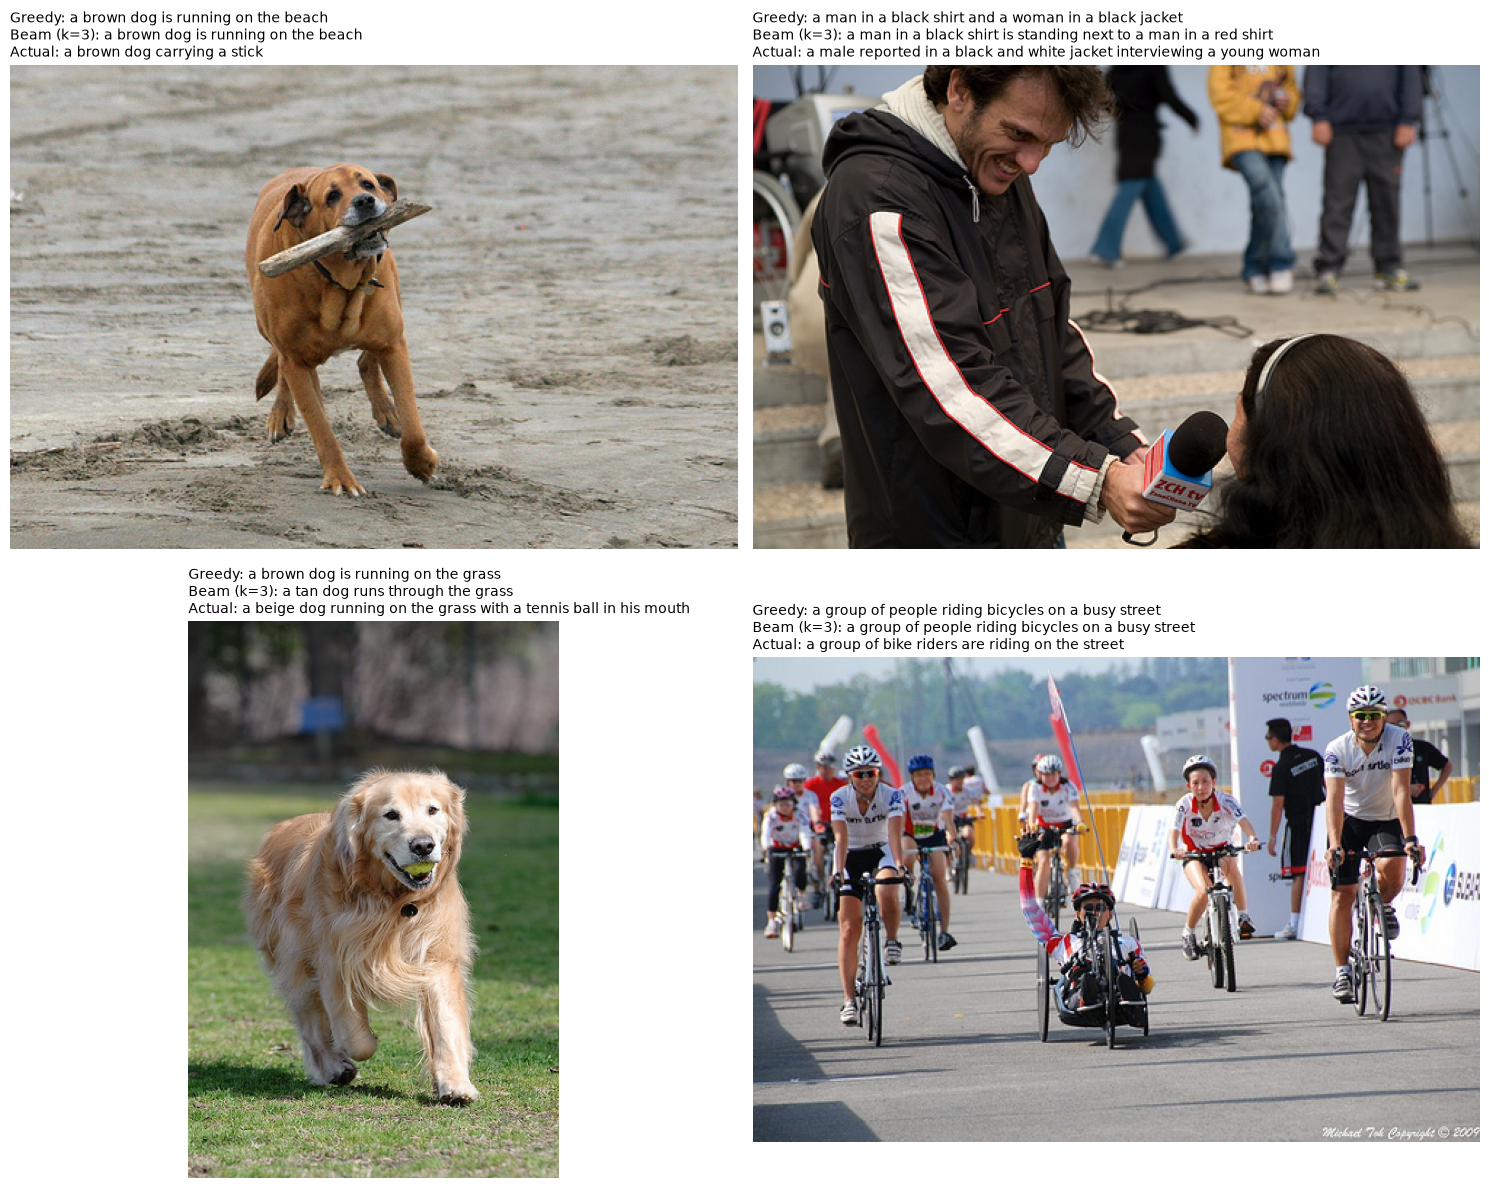

In [6]:
# Helper: Greedy Decoder (for comparison)
def generate_caption_greedy(image_name, model, features, vocab, max_len=35):
    if image_name not in features: return []
    model.eval()
    feat = torch.tensor(features[image_name], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        h, c = model.init_hidden_state(feat.unsqueeze(1))
        word = torch.tensor([vocab.word2idx['<start>']]).to(device)
        caption = []
        for i in range(max_len):
            embeddings = model.embedding(word).unsqueeze(1)
            attention_weighted_encoding, _ = model.attention(feat.unsqueeze(1), h)
            gate = model.sigmoid(model.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = model.decode_step(torch.cat([embeddings.squeeze(1), attention_weighted_encoding], dim=1), (h, c))
            preds = model.fc(h)
            predicted_idx = preds.argmax(dim=1).item()
            if predicted_idx == vocab.word2idx['<end>']: break
            caption.append(vocab.idx2word[predicted_idx])
            word = torch.tensor([predicted_idx]).to(device)
    return caption

# Plot 4 random validation images
sample_imgs = np.random.choice(list(val_imgs), 4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, img_name in zip(axes.flatten(), sample_imgs):
    img_path = os.path.join(IMAGES_DIR, img_name)
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        
        # Generation
        greedy_cap = ' '.join(generate_caption_greedy(img_name, model, image_features, vocab))
        beam_cap = ' '.join(generate_caption_beam_search(img_name, model, image_features, vocab, beam_size=3))
        actual = ' '.join(actual_captions[img_name][0]) # Show first GT
        
        title = f"Greedy: {greedy_cap}\nBeam (k=3): {beam_cap}\nActual: {actual}"
        ax.set_title(title, fontsize=10, loc='left', wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.show()

## ✅ Step 7: Advanced Metrics (METEOR & ROUGE-L)
Aside from BLEU, academic papers heavily rely on **METEOR** (which understands synonyms) and **ROUGE-L** (which looks at the longest matching sequence of words).

In [7]:
!pip install rouge-score

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=25027 sha256=126aa387569bd29b1abf2e4dde38e28b0e34ababeb711f31ddaa92e5f9233d7b
  Stored in directory: c:\users\chvas\appdata\local\pip\cache\wheels\1e\19\43\8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [8]:
import nltk
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from tqdm import tqdm

# Ensure NLTK WordNet is downloaded for METEOR
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Calculating Advanced Metrics (METEOR & ROUGE-L)...")

meteor_scores = []
rouge_l_scores = []
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# Loop through the predictions we already generated
for refs, pred in tqdm(zip(references, predictions), total=len(predictions)):
    # METEOR takes references as list of strings, prediction as string
    # We currently have refs as list of list of words, pred as list of words.
    
    pred_str = ' '.join(pred)
    refs_str = [' '.join(ref) for ref in refs]
    
    # 1. Compute METEOR
    m_score = meteor_score([ref.split() for ref in refs_str], pred_str.split())
    meteor_scores.append(m_score)
    
    # 2. Compute ROUGE-L (taking max over all 5 references)
    r_score = max(scorer.score(ref, pred_str)['rougeL'].fmeasure for ref in refs_str)
    rouge_l_scores.append(r_score)

avg_meteor = np.mean(meteor_scores)
avg_rouge_l = np.mean(rouge_l_scores)

print("\n====== ADVANCED SCORES ======")
print(f"METEOR : {avg_meteor * 100:.2f}")
print(f"ROUGE-L: {avg_rouge_l * 100:.2f}")
print("=============================")

Calculating Advanced Metrics (METEOR & ROUGE-L)...


100%|██████████| 200/200 [00:05<00:00, 38.99it/s]


====== ADVANCED SCORES ======
METEOR : 41.15
ROUGE-L: 46.45


## ✅ Step 8: Token-Level Accuracy
*Note: In Image Captioning, BLEU/METEOR/ROUGE are the true standards because there are many valid ways to describe an image. However, if you need a strict "Accuracy %" for your project requirements, we can calculate **Token-Level Accuracy**.*

This calculates: Out of all the words the model was supposed to predict, what percentage did it predict exactly correct?

In [9]:
print("Calculating Token-Level Accuracy (Teacher Forcing)...")

correct_tokens = 0
total_tokens = 0

# We will test this on our eval_imgs subset
for img_name in tqdm(eval_imgs, desc="Accuracy"):
    feat = torch.tensor(image_features[img_name], dtype=torch.float32).unsqueeze(0).to(device)
    
    # We compare against the first ground truth caption
    gt_words = actual_captions[img_name][0]
    gt_tokens = [vocab.word2idx['<start>']] + [vocab(w) for w in gt_words] + [vocab.word2idx['<end>']]
    
    h, c = model.init_hidden_state(feat.unsqueeze(1))
    
    # Teacher forcing: feed the ground truth word to predict the next word
    for i in range(len(gt_tokens) - 1):
        current_word = torch.tensor([gt_tokens[i]]).to(device)
        target_next_word = gt_tokens[i+1]
        
        embeddings = model.embedding(current_word).unsqueeze(1)
        attention_weighted_encoding, _ = model.attention(feat.unsqueeze(1), h)
        gate = model.sigmoid(model.f_beta(h))
        attention_weighted_encoding = gate * attention_weighted_encoding
        
        h, c = model.decode_step(
            torch.cat([embeddings.squeeze(1), attention_weighted_encoding], dim=1),
            (h, c)
        )
        
        preds = model.fc(h)
        predicted_idx = preds.argmax(dim=1).item()
        
        if predicted_idx == target_next_word:
            correct_tokens += 1
        total_tokens += 1

accuracy = (correct_tokens / total_tokens) * 100

print("\n====== STRICT ACCURACY ======")
print(f"Token-Level Accuracy: {accuracy:.2f}%")
print("=============================")

Calculating Token-Level Accuracy (Teacher Forcing)...


Accuracy: 100%|██████████| 200/200 [00:04<00:00, 42.40it/s]


====== STRICT ACCURACY ======
Token-Level Accuracy: 43.66%
